In [1]:
# ==========================================
# Assignment 8.3 - G7 Trade Network Comparison
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline

In [2]:
# ==========================================
# Load the datasets
# ==========================================

trade_2024 = pd.read_excel("g7_exports_2024.xlsx")
trade_2023 = pd.read_excel("g7_exports_2023.xlsx")

In [3]:
print("2024:")
display(trade_2024.head())

print("2023:")
display(trade_2023.head())

2024:


,REF_AREA,CA,DE,FR,GB,IT,JP,US
0,CA,NaN,4933.0,3213.0,20628.0,2382.0,10918.0,435114.0
1,DE,13956.0,NaN,125670.0,86798.0,87382.0,23313.0,174482.0
2,FR,4264.0,83435.0,NaN,39475.0,51861.0,9892.0,50937.0
3,GB,8880.0,40941.0,29778.0,NaN,11760.0,9307.0,73688.0
4,IT,6640.0,76817.0,67350.0,29671.0,NaN,8908.0,70075.0


2023:


,REF_AREA,CA,DE,FR,GB,IT,JP,US
0,CA,NaN,5201.0,3159.0,10489.0,1978.0,11668.0,441333.0
1,DE,13751.0,NaN,129467.0,84648.0,92270.0,21866.0,170537.0
2,FR,4275.0,88443.0,NaN,38812.0,57342.0,7228.0,47489.0
3,GB,8850.0,42134.0,30439.0,NaN,12983.0,7880.0,76442.0
4,IT,6828.0,80776.0,68715.0,28161.0,NaN,8687.0,72653.0


In [4]:
# ==========================================
# Convert to edge lists
# ==========================================

trade_2024_long = trade_2024.melt(
    id_vars="REF_AREA",
    var_name="Importer",
    value_name="Exports"
)

trade_2023_long = trade_2023.melt(
    id_vars="REF_AREA",
    var_name="Importer",
    value_name="Exports"
)

In [5]:
# ==========================================
# Clean the edge lists
# ==========================================

trade_2024_long.rename(columns={"REF_AREA": "Exporter"}, inplace=True)
trade_2023_long.rename(columns={"REF_AREA": "Exporter"}, inplace=True)

trade_2024_long.dropna(inplace=True)
trade_2023_long.dropna(inplace=True)

In [6]:
# ==========================================
# Create directed graphs
# ==========================================

G_2024 = nx.from_pandas_edgelist(
    trade_2024_long,
    source="Exporter",
    target="Importer",
    edge_attr="Exports",
    create_using=nx.DiGraph()
)

G_2023 = nx.from_pandas_edgelist(
    trade_2023_long,
    source="Exporter",
    target="Importer",
    edge_attr="Exports",
    create_using=nx.DiGraph()
)

In [7]:
# ==========================================
# Network visualisation settings
# ==========================================

options = {
    "node_color": "lightblue",
    "edge_color": "lightblue",
    "node_size": 1800,
    "width": 1.5,
    "with_labels": True,
}

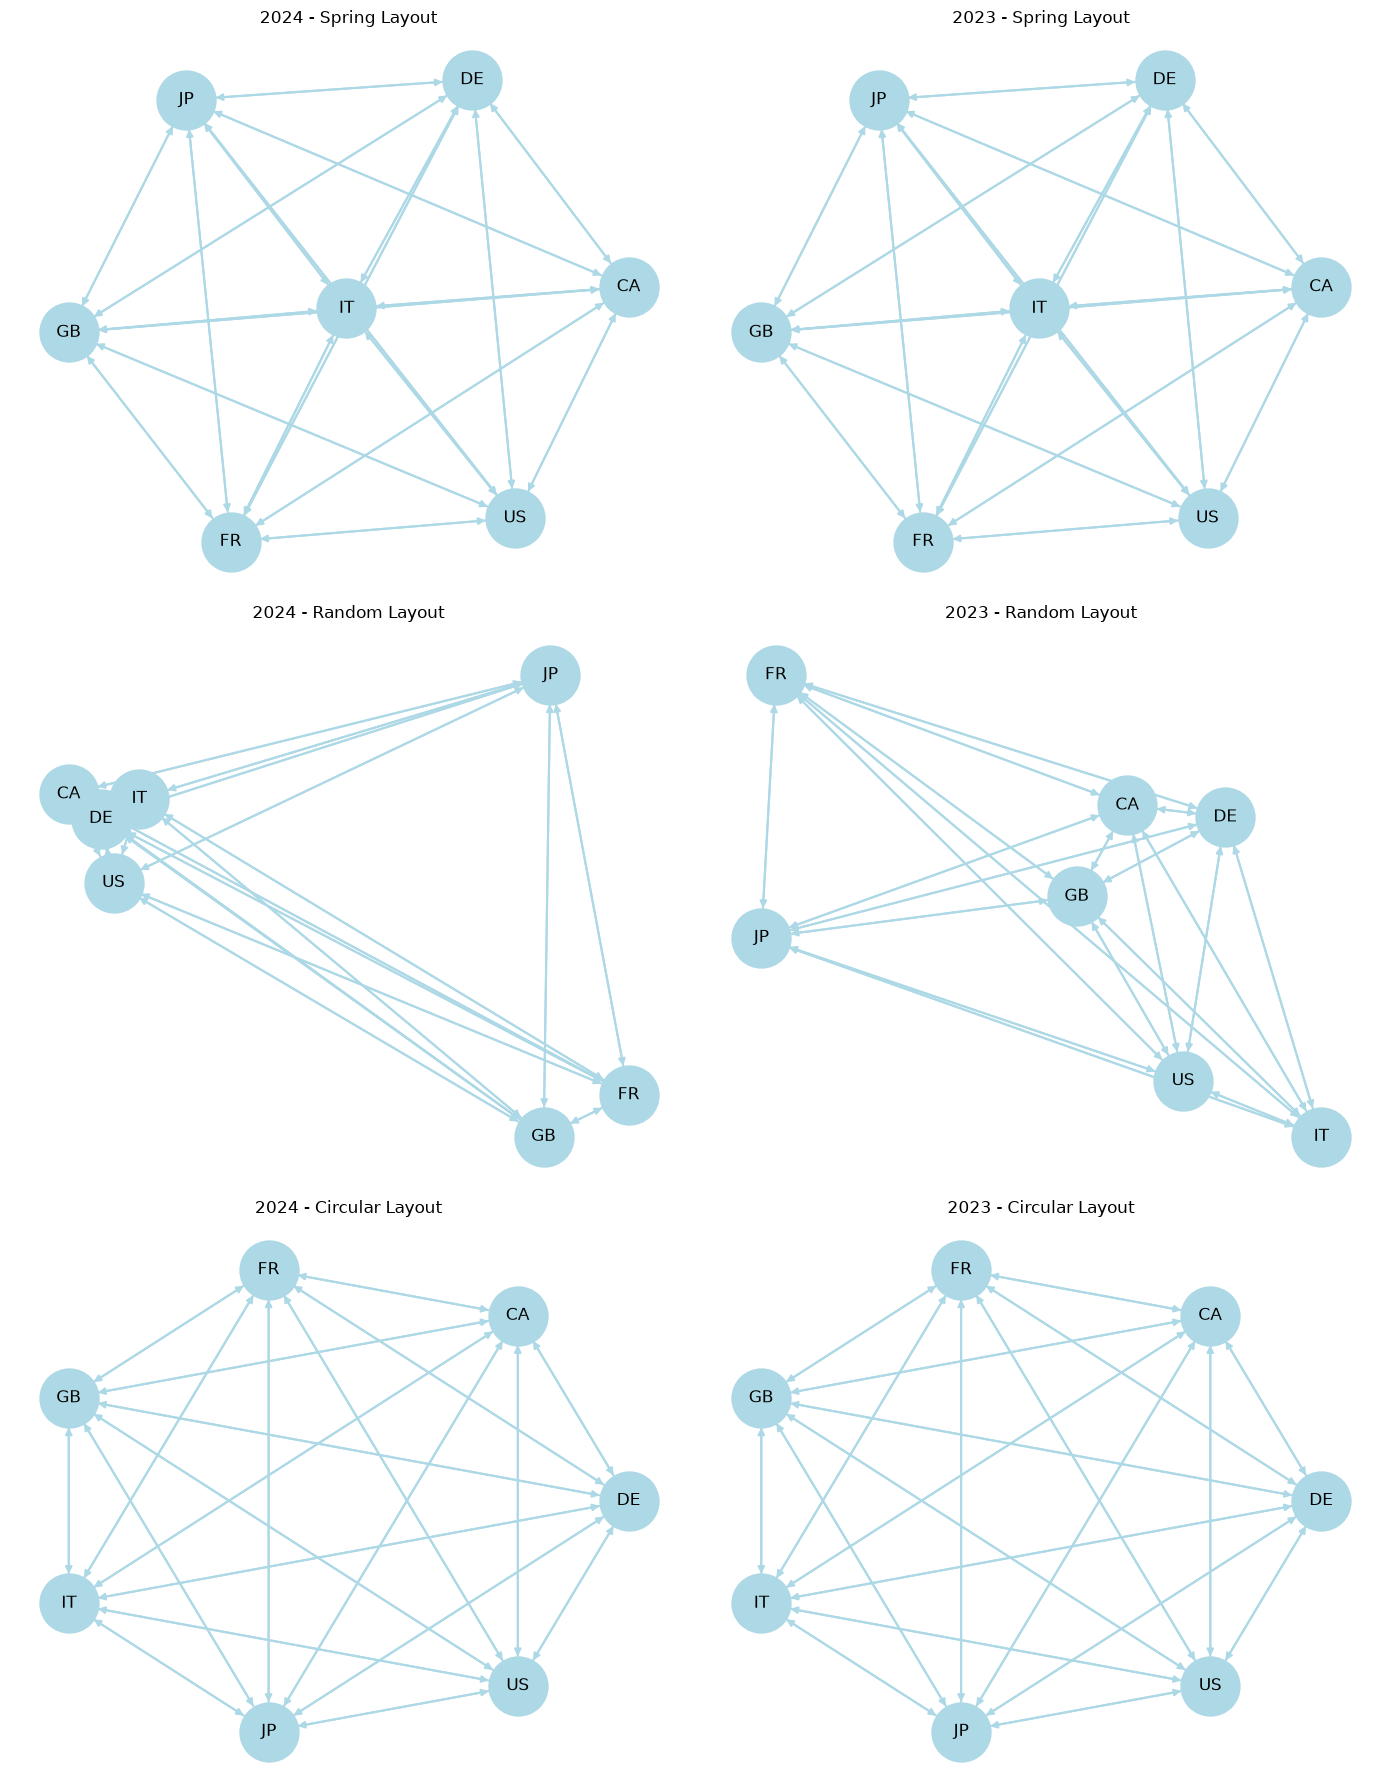

In [8]:
# ==========================================
# Compare 2024 and 2023 networks
# ==========================================

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

layouts = [
    ("Spring Layout", nx.spring_layout),
    ("Random Layout", nx.random_layout),
    ("Circular Layout", nx.circular_layout),
]

for i, (layout_name, layout_func) in enumerate(layouts):

    # Use the same layout function for both graphs
    if layout_name == "Spring Layout":
        pos_2024 = layout_func(G_2024, seed=42)
        pos_2023 = layout_func(G_2023, seed=42)
    else:
        pos_2024 = layout_func(G_2024)
        pos_2023 = layout_func(G_2023)

    # 2024 graph
    plt.sca(axes[i, 0])
    nx.draw(G_2024, pos_2024, **options)
    axes[i, 0].set_title(f"2024 - {layout_name}")
    axes[i, 0].axis("off")

    # 2023 graph
    plt.sca(axes[i, 1])
    nx.draw(G_2023, pos_2023, **options)
    axes[i, 1].set_title(f"2023 - {layout_name}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()